# Uber A/B Test Analysis

## What This Notebook Is About

This notebook analyses a **randomised controlled experiment (A/B test)** run by Uber to evaluate whether reducing the cancellation window improves service quality. It teaches the full workflow: visualise the data, compute summary statistics, run hypothesis tests, and draw actionable conclusions.

---

### The Business Question

Uber ran a trial with two groups :
- **Group A (control)**: Riders could wait up to **5 minutes**
- **Group B (treatment)**: Riders could wait up to **2 minutes**


Two outcomes were measured over 63 time periods per group:
1. **Cancellation rate**: % of accepted rides that were cancelled (lower is better; target ≤ 4%)
2. **Match rate**: % of ride requests successfully matched with a driver (higher is better)

---

### What Is an A/B Test?

An **A/B test** (also called a randomised controlled experiment) compares two groups that differ on exactly ONE thing — the "treatment" — while everything else is held constant.

**Why randomise?** If you let drivers self-select into groups, the group choosing the shorter window might be more conscientious drivers to begin with — making the treatment *look* effective even if it isn't. Random assignment removes this selection bias and allows causal inference.

---

### The Statistical Framework

| Question | Tool |
|---|---|
| Is Group A's cancellation rate different from 4%? | **One-sample t-test** |
| Is Group B's cancellation rate different from 4%? | **One-sample t-test** |
| Do the two groups differ in cancellation rate? | **Two-sample Welch t-test** |
| Do the two groups differ in match rate? | **Two-sample Welch t-test** |

**Why Welch's t-test (equal_var=False)?** The standard Student's t-test assumes equal variance in both groups. Welch's version doesn't make this assumption — it's more conservative and more reliable when variance might differ. This is almost always the better default.

---

### How to Read the Test Output

```
t = 5.51,  p = 0.0000  ***
```
- **t-statistic**: how many standard errors the observed difference is from zero. Large |t| → data is far from H₀.
- **p-value**: probability of seeing a result this extreme (or more) if H₀ is true. `p < 0.05` → reject H₀.
- **Stars**: `*` = p < 0.05, `**` = p < 0.01, `***` = p < 0.001, `ns` = not significant

---

### What You Will Learn

| Concept | Where |
|---|---|
| Plotting a time series scatter by group | Section 2 |
| Stripplot + pointplot layering (jitter + CI) | Sections 3 & 4 |
| One-sample t-test: `stats.ttest_1samp()` | Section 6 |
| Two-sample Welch t-test: `stats.ttest_ind(equal_var=False)` | Section 6 |
| `stats.t.interval()`: computing a CI from the t-distribution | Section 6 |
| `stats.sem()`: standard error of the mean | Section 6 |
| Interpreting trade-offs: one metric improves, another worsens | Section 6 |

---

### Libraries Used
- **`scipy.stats`** — `ttest_1samp`, `ttest_ind`, `t.interval`, `sem`
- **`pandas`** — data loading, groupby, describe
- **`seaborn`** — stripplot, pointplot, scatterplot
- **`matplotlib`** — figure sizing, reference lines

In [ ]:
# ==============================================================================
# 1. SETUP AND DATA LOADING
# ==============================================================================
# Standard imports for data science work:
#   pandas  → DataFrame manipulation, loading CSVs
#   numpy   → numerical operations (sqrt, var, etc.)
#   seaborn → statistical visualisation (stripplot, pointplot, scatterplot)
#   scipy.stats → hypothesis tests (ttest_1samp, ttest_ind) and CI helpers
#
# plt.style.use('seaborn-v0_8-whitegrid') sets a clean white background with
# light grid lines. The 'v0_8' prefix is needed in newer matplotlib versions
# because the old 'seaborn-whitegrid' style name was renamed.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Load the Uber A/B test data from GitHub
# 126 rows = 63 time periods × 2 groups (A and B)
uber = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/uber.csv")

# Pre-filter into separate group DataFrames — used in hypothesis tests below
group_a = uber[uber['group'] == 'A - 5 min']   
group_b = uber[uber['group'] == 'B - 2min']    

In [6]:
uber.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   period_start       126 non-null    datetime64[us]
 1   cancellation_rate  126 non-null    float64       
 2   match_rate         126 non-null    float64       
 3   group              126 non-null    str           
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 4.1 KB


## 2. Cancellation Rate Over Time

In [ ]:
# ==============================================================================
# 2. Cancellation Rate Over Time — Time Series Plot
# ==============================================================================
# This chart plots both groups on the same axes against time.
# Goal: check for any time trends, seasonality, or structural breaks.
# If both groups are on a similar time trend, that rules out time as a confounder.
#
# hue='group': seaborn automatically colours each group differently and adds a legend.
# Each dot = one time period's cancellation rate for that group.
#
# ax.axhline(y=4, ...): draws a horizontal reference line at the 4% target.
# This is Uber's operational threshold — anything above = too many cancellations.
# "axhline" = "axis horizontal line" (axvline for vertical lines)
# linestyle="--" = dashed line (visually distinct from data points)

fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=uber,
    x='period_start',     # x-axis: time period
    y='cancellation_rate', # y-axis: cancellation rate (%)
    hue='group',          # colour by group (A vs B)
    ax=ax
)

# Reference line at 4% — the target cancellation rate threshold
ax.axhline(y=4, color="#001e62", linewidth=1.1, linestyle="--", label="4% target")

ax.set_title("Cancellation Rate for groups A & B", fontsize=16)
ax.set(xlabel=None, ylabel="Cancellation Rate")
ax.legend()

plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR:
#   - Are the two groups visually separated? (A above B = treatment is working)
#   - Is Group B consistently near or below the 4% target?
#   - Is there a trend over time, or is the separation consistent throughout?

## 3. Cancellation Rate by Group (with 95% CI)

In [ ]:
# ==============================================================================
# 3. Cancellation Rate by Group — Stripplot + Pointplot (two-layer chart)
# ==============================================================================
# This chart layers TWO seaborn plots on the SAME axes (ax):
#
# LAYER 1 — sns.stripplot:
#   Shows every individual data point as a dot, "jittered" vertically so they
#   don't all overlap at the same y-position. This reveals the full distribution:
#   how spread out the data is, whether there are outliers, etc.
#   jitter=0.05: small random y-offset added to each point (avoids overplotting)
#   alpha=0.7: semi-transparent points (so dense areas look darker)
#
# LAYER 2 — sns.pointplot:
#   Draws a large dot (the mean) with error bars (95% CI for the mean).
#   errorbar=('ci', 95) → 95% confidence interval
#   The CI shows the range where the true group mean plausibly lies.
#   color='red', markersize=20 → big red dot to stand out against the stripplot
#
# WHY LAYER THESE TWO?
#   Pointplot alone: shows mean + CI but hides the raw data distribution
#   Stripplot alone: shows all points but makes comparing group means hard
#   Together: the best of both worlds — see the full picture AND the summary

fig, ax = plt.subplots(figsize=(10, 6))

# Layer 1: Individual observations as jittered points
sns.stripplot(
    data=uber, x='cancellation_rate', y='group',
    ax=ax, alpha=0.7, jitter=0.05
)

# Layer 2: Group mean with 95% CI error bars (plotted on the SAME ax)
sns.pointplot(
    data=uber, x='cancellation_rate', y='group',
    ax=ax, join=False,              # don't connect group means with a line
    errorbar=('ci', 95),            # show 95% confidence interval bars
    color='red', markersize=20, linewidth=3, capsize=0.1
)

# --- Annotate the mean value directly on the red dot ---
# This makes it easy to read exact mean values without squinting at the axis
group_means = uber.groupby('group')['cancellation_rate'].mean()
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    ax.text(mean_val, i,             # x=mean value, y=group index
            f'{mean_val:.2f}',
            color='white',           # white text on the red dot
            fontsize=8, fontweight='bold',
            ha='center', va='center')

# Reference line at the 4% target
ax.axvline(x=4, color="#001e62", linestyle="--", label="4% target")
ax.set_title("Cancellation Rate for groups A & B", loc='left', fontsize=16)
ax.set(xlabel="Cancellation Rate", ylabel=None)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

## 4. Match Rate by Group (with 95% CI)

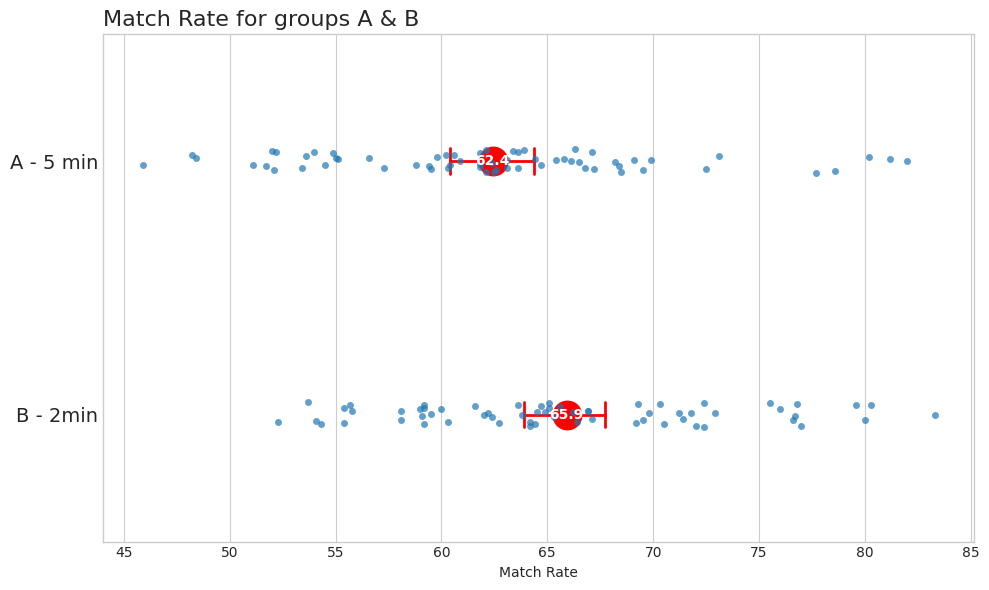

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(
    data=uber, x='match_rate', y='group',
    ax=ax, alpha=0.7, jitter=0.05
)

sns.pointplot(
    data=uber, x='match_rate', y='group',
    ax=ax, join=False, errorbar=('ci', 95),
    color='red', markersize=20, linewidth=2, capsize=0.1
)

# Mean labels
group_means_match = uber.groupby('group')['match_rate'].mean()
for i, group in enumerate(group_means_match.index):
    mean_val = group_means_match[group]
    ax.text(mean_val, i, f'{mean_val:.1f}',
            color='white', fontsize=10, fontweight='bold',
            ha='center', va='center')

ax.set_title("Match Rate for groups A & B", loc='left', fontsize=16)
ax.set(xlabel="Match Rate", ylabel=None)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [13]:
print("--- Cancellation Rate by Group ---")
display(
    uber.groupby('group')['cancellation_rate']
    .describe().round(2).reset_index()
)

print("--- Match Rate by Group ---")
display(
    uber.groupby('group')['match_rate']
    .describe().round(2).reset_index()
)

--- Cancellation Rate by Group ---


,group,count,mean,std,min,25%,50%,75%,max
0,A - 5 min,63.0,4.85,0.83,3.6,4.30,4.7,5.15,7.1
1,B - 2min,63.0,4.12,0.65,2.7,3.75,4.1,4.50,5.8


--- Match Rate by Group ---


,group,count,mean,std,min,25%,50%,75%,max
0,A - 5 min,63.0,62.43,8.01,45.9,56.95,62.4,66.65,82.0
1,B - 2min,63.0,65.92,7.52,52.3,59.75,65.1,71.30,83.3


## 6. Hypothesis Testing

### One-sample t-tests: Is each group's cancellation rate = 4%?
### Two-sample t-tests: Do the groups differ from each other?

In [ ]:
# ==============================================================================
# 6. Hypothesis Testing — One-sample and Two-sample t-tests
# ==============================================================================
# We define TWO reusable helper functions, then call them for our analysis.
# Defining functions avoids copy-paste and makes the test logic consistent.
#
# ── FUNCTION 1: one_sample_ttest_summary ──────────────────────────────────────
# Tests: "Is this group's mean equal to a specific target value?"
# H₀: μ = popmean  (e.g. is Group A's mean cancellation rate = 4%?)
# H₁: μ ≠ popmean  (two-sided: could be above or below the target)
#
# stats.ttest_1samp(x, popmean)
#   Returns (t_statistic, p_value)
#   t = (x̄ − popmean) / (s / √n)  — how many standard errors from the target
#
# stats.t.interval(0.95, df, loc, scale)
#   Computes the 95% CI directly from the t-distribution.
#   loc  = x.mean()     — centre of the interval
#   scale = stats.sem(x) — standard error of the mean = s / √n
#   df = n - 1          — degrees of freedom (accounts for small sample)
#
# stats.sem(x) = standard error of the mean = sample_std / sqrt(n)
#   This measures how precisely we've estimated the mean from the sample.
#   Smaller SE → narrower CI → more precise estimate.
#
# ── FUNCTION 2: two_sample_ttest_summary ──────────────────────────────────────
# Tests: "Do Groups A and B have the same mean?"
# H₀: μ_A = μ_B  (no difference between groups)
# H₁: μ_A ≠ μ_B  (two-sided: either direction)
#
# stats.ttest_ind(x, y, equal_var=False)
#   equal_var=False → Welch's t-test (does NOT assume equal variance)
#   This is the DEFAULT choice for two-sample tests — more conservative and
#   valid even when the two groups have different spreads (different SDs).
#   equal_var=True → Student's t-test (assumes σ_A = σ_B, rarely appropriate)
#
# WELCH'S DEGREES OF FREEDOM:
#   df = (s²_A/n_A + s²_B/n_B)² / [(s²_A/n_A)²/(n_A−1) + (s²_B/n_B)²/(n_B−1)]
#   This complex formula adjusts df to account for unequal variances.
#   scipy computes this internally — we compute it manually here only to report it.
#
# CI FOR THE DIFFERENCE:
#   We compute a 95% CI around (mean_A − mean_B).
#   If this CI excludes 0, the difference is statistically significant.
#   If it includes 0, we cannot rule out that both groups have the same mean.

def one_sample_ttest_summary(data, col, popmean, group_name):
    x = data[col].dropna()
    t, p = stats.ttest_1samp(x, popmean)
    ci = stats.t.interval(0.95, df=len(x)-1, loc=x.mean(), scale=stats.sem(x))
    print(f"--- One-Sample T-Test: {group_name} | {col} vs μ = {popmean} ---")
    print(f"  n         : {len(x)}")
    print(f"  mean      : {x.mean():.4f}")
    print(f"  std       : {x.std(ddof=1):.4f}")          # ddof=1 = sample std (not population)
    print(f"  95% CI    : [{ci[0]:.4f}, {ci[1]:.4f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {len(x)-1}")
    print(f"  p-value   : {p:.4f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}\n")
    # Stars: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant (p≥0.05)

def two_sample_ttest_summary(a, b, col, label_a, label_b):
    x, y = a[col].dropna(), b[col].dropna()
    t, p = stats.ttest_ind(x, y, equal_var=False)    # Welch's t-test

    # Welch's degrees of freedom (Satterthwaite approximation)
    df = (x.var()/len(x) + y.var()/len(y))**2 / (
          (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))

    diff = x.mean() - y.mean()    # point estimate: difference in means

    # 95% CI for the DIFFERENCE in means
    ci = stats.t.interval(0.95, df=df, loc=diff,
                          scale=np.sqrt(x.var()/len(x) + y.var()/len(y)))

    print(f"--- Two-Sample Welch T-Test: {col} | {label_a} vs {label_b} ---")
    print(f"  n         : {len(x)}  vs  {len(y)}")
    print(f"  mean      : {x.mean():.4f}  vs  {y.mean():.4f}")
    print(f"  std       : {x.std(ddof=1):.4f}  vs  {y.std(ddof=1):.4f}")
    print(f"  diff      : {diff:.4f}")
    print(f"  95% CI    : [{ci[0]:.4f}, {ci[1]:.4f}]")   # if excludes 0 → significant
    print(f"  t         : {t:.4f}")
    print(f"  df        : {df:.2f}")
    print(f"  p-value   : {p:.4f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}\n")

# --- Run all four tests ---
# Q1: Is Group A's cancellation rate statistically different from 4%?
one_sample_ttest_summary(group_a, 'cancellation_rate', popmean=4, group_name='Group A')

# Q2: Is Group B's cancellation rate statistically different from 4%?
one_sample_ttest_summary(group_b, 'cancellation_rate', popmean=4, group_name='Group B')

# Q3: Do the two groups differ significantly in cancellation rate?
two_sample_ttest_summary(group_a, group_b, 'cancellation_rate', 'Group A', 'Group B')

# Q4: Do the two groups differ significantly in match rate?
#     IMPORTANT: this test reveals the TRADE-OFF — the shorter window may hurt matching
two_sample_ttest_summary(group_a, group_b, 'match_rate', 'Group A', 'Group B')